<h1>Модель для предсказания массы черепахи</h1>

## Подключение и настройка библиотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import phik
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Lasso, Ridge, SGDRegressor

## Загрузка датасета

In [2]:
try:
    df = pd.read_csv(r"turtles.csv", sep="\t", decimal=",")
except:
    df = pd.read_csv('https://code.s3.yandex.net/datasets/turtles.csv', sep="\t", decimal=",")
df_or = df.copy()

## Исследовательский анализ данных

### Рассмотрим исходный датафрейм:

In [3]:
df.info()
df.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 8861 entries, 0 to 8860
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   8861 non-null   int64  
 1   binomial_name        8812 non-null   str    
 2   registration number  8832 non-null   str    
 3   shell_length         8774 non-null   float64
 4   shell_width          8861 non-null   int64  
 5   head_length          8715 non-null   float64
 6   head_width           8715 non-null   float64
 7   flipper_length_1     8861 non-null   int64  
 8   flipper_width_1      8861 non-null   int64  
 9   flipper_length_2     8861 non-null   int64  
 10  flipper_width_2      8861 non-null   int64  
 11  flipper_length_3     8760 non-null   float64
 12  flipper_width_3      8760 non-null   float64
 13  flipper_length_4     8760 non-null   float64
 14  flipper_width_4      8760 non-null   float64
 15  circle_count         8861 non-null   int64  
 16 

,id,binomial_name,registration number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight
0,20438,Caretta caretta,d89af72662f49ece4d09dec75a8b0166,700.0,381,112.0,82.0,356,205,331,185,270.0,180.0,273.0,144.0,63,3.0,NaN,1703159226,87.687
1,19034,Lepidochelys olivacea,1579c64777de4db1c16e8b7b0d19c45e,341.0,295,65.0,48.0,216,190,229,186,164.0,182.0,180.0,149.0,0,1.0,1.0,1689428175,26.949
2,24689,LEPIDOCHELYS OLIVACEA,bfcec01187569615087e4d777c44985a,408.0,343,71.0,70.0,308,224,285,232,264.0,179.0,268.0,176.0,0,3.0,NaN,1745783111,30.016
3,17945,Lepidochelys Olivacea,2c159675aa28f0ea566fce2090bf4c82,512.0,432,98.0,95.0,334,317,364,284,NaN,NaN,NaN,NaN,3,4.0,1.0,1677757151,33.917
4,24543,lepidochelys olivacea,ecd22499761e2ac56a6d8eb765ec566d,408.0,307,50.0,54.0,280,168,269,218,199.0,165.0,209.0,180.0,0,4.0,1.0,1744455613,28.511
5,25045,Lepidochelys olivacea,1b076bdf8f9ed92f370f64ffd28b7dd6,341.0,254,54.0,55.0,250,204,240,217,197.0,152.0,185.0,154.0,0,1.0,NaN,1749366080,27.513
6,23228,Lepidochelys olivacea,ad587cf0ebf5ac3a337fc55f91b16086,606.0,526,114.0,91.0,489,407,460,316,440.0,260.0,326.0,300.0,32,2.0,NaN,1731882409,40.228
7,19458,Lepidochelys olivacea,a9d0a18fc14b993b95ea02a314aa4aee,600.0,551,104.0,109.0,411,328,396,338,356.0,258.0,321.0,266.0,20,3.0,NaN,1693572979,38.838
8,25241,Chelonia mydas,0d05dca974d9f624d9c9f8e38817f827,742.0,652,118.0,147.0,411,386,507,389,414.0,368.0,311.0,325.0,66,4.0,1.0,1751228603,56.352
9,20199,Lepidochelys olivacea,baa40598df8e5120e81c65a847a5a5be,399.0,336,NaN,NaN,264,240,288,234,215.0,161.0,226.0,186.0,0,4.0,NaN,1700915750,29.823


#### Данные исходного датасета включают:
- 8861 строк данных
- Обнаружены пропуски в строке целевой переменной  weight, их необходимо удалить
- Больше половины значений в строке shell_crack пропуски судя по значениеям Nan означает 0 трещин необходимо сделать обработку типов данных 
- Возможны дубликаты строк из-за разного регистра в названии черепахи
- У нескольких строк отсутсвует binomial_name
- Столбцы registration number, timestamp measure_count не несут в себе смысла для модели предсказания массы их можно исключить
- flipper_length и flipper_width для значений 1 и 2 имеют тип int а для 3 и 4 тип float возможно это связано с наличием пропусков поэтому после обработку требуется сменить тип

### Проведем фильтрацию взяв только необходимые данные
- Удалим столбцы  id, registration number, timestamp
- Сделаем отбор по интересующим нас видам, предварительно превидя имя к одному регистру

In [4]:
df['binomial_name'] = df['binomial_name'].str.lower()
data = df[df['binomial_name'] =='chelonia mydas']
print(f"Всего интересующих особей: {len(data)}")

Всего интересующих особей: 2829


In [5]:
data.drop(['registration number', 'timestamp', 'measure_count'], axis=1, inplace=True)
data.columns

Index(['id', 'binomial_name', 'shell_length', 'shell_width', 'head_length',
       'head_width', 'flipper_length_1', 'flipper_width_1', 'flipper_length_2',
       'flipper_width_2', 'flipper_length_3', 'flipper_width_3',
       'flipper_length_4', 'flipper_width_4', 'circle_count', 'shell_crack',
       'weight'],
      dtype='str')

### Проведем обработку пропусков и дубликатов
- найдем количество пропусков в каждом стобце и либо заменим из на фиксированное значение либо удалим
- найдем явные и неявные дубликаты в данных и удалим их

####  Проанализируем пропуски:

In [6]:
for col in data.columns:
    missing = data[col].isna().sum()
    print(f"{col}: {missing} пропусков {(missing / len(data)) * 100} %")

id: 0 пропусков 0.0 %
binomial_name: 0 пропусков 0.0 %
shell_length: 35 пропусков 1.2371862849063273 %
shell_width: 0 пропусков 0.0 %
head_length: 39 пропусков 1.378579003181336 %
head_width: 39 пропусков 1.378579003181336 %
flipper_length_1: 0 пропусков 0.0 %
flipper_width_1: 0 пропусков 0.0 %
flipper_length_2: 0 пропусков 0.0 %
flipper_width_2: 0 пропусков 0.0 %
flipper_length_3: 31 пропусков 1.0957935666313185 %
flipper_width_3: 31 пропусков 1.0957935666313185 %
flipper_length_4: 31 пропусков 1.0957935666313185 %
flipper_width_4: 31 пропусков 1.0957935666313185 %
circle_count: 0 пропусков 0.0 %
shell_crack: 2152 пропусков 76.06928243195476 %
weight: 3 пропусков 0.10604453870625664 %


- столбецы 'flipper_length_3', 'flipper_width_3', 'flipper_length_4', 'flipper_width_4', 'head_length', 'head_width', 'shell_length' обладают незначительным количеством пропусков проверим сколько данных упускаем в случае удаления
- столбец shell_crack Nan значения возможно означают что трещин нет проверим теорию и заменим значением 0 при смене типов
- столбцы с пропускамив weight удаляем так как  'weight' целевая переменная

In [7]:
data = data.dropna(subset=['weight'])
cols_with_na = ['flipper_length_3', 'flipper_width_3', 'flipper_length_4', 'flipper_width_4', 'head_length', 'head_width', 'shell_length']
afterDrop_len = len(data.dropna(subset=cols_with_na))
current_len = len(data)
print("Размер исходного data:", current_len)
print("Размер после удаления:", afterDrop_len)
print(f"Строк удалено: {current_len - afterDrop_len}({(current_len - afterDrop_len) / current_len * 100}%)", )

Размер исходного data: 2826
Размер после удаления: 2724
Строк удалено: 102(3.6093418259023355%)


В случае удаленния данных теряем около 3.7% строк

Проверим уникальные значения shell_crack и распределение относительно возроста, чтобы проверить теорию что пропуски - значение 0

In [8]:
print("Уникальные значения shell_crack:")
print(data['shell_crack'].unique())
print(data['shell_crack'].value_counts(dropna=False))
mask = data['shell_crack'].isna()

Уникальные значения shell_crack:
[ 1.  5. nan  3.  2.  4.]
shell_crack
NaN    2152
1.0     437
2.0      89
3.0      67
5.0      56
4.0      25
Name: count, dtype: int64


Значения 0 ненайдены значит пропуски соответствуют значениям 0

In [9]:
data['shell_crack'] = data['shell_crack'].fillna(0)

#### Проверка на дубликаты

In [10]:
explicit_sum = data.duplicated().sum()
print("Полных дубликаты:", explicit_sum)
if explicit_sum > 0:
    print(data[data.duplicated()].head(4))
data.drop_duplicates(inplace=True)
print("\n")
id_dupl_count = data.duplicated(subset=['id']).sum()
print("Дубликаты по id:", id_dupl_count)
if id_dupl_count > 0:
    dup_id = data[data.duplicated(subset=['id'], keep=False)]
    print(dup_id.sort_values('id').head(4))
print("\n")
cols_wo_id = data.columns.drop('id')
wo_id_dups_count = data.duplicated(subset=cols_wo_id).sum()
print("Дубликаты без учета id:", wo_id_dups_count)
if wo_id_dups_count > 0:
    dup_no_id = data[data.duplicated(subset=cols_wo_id, keep=False)]
    print(dup_no_id.head(4))

Полных дубликаты: 340
         id   binomial_name  shell_length  shell_width  head_length  \
7842  20833  chelonia mydas           NaN          849        184.0   
7844  22670  chelonia mydas         792.0          690        144.0   
7845  23641  chelonia mydas         867.0          809        177.0   
7847  25078  chelonia mydas         854.0          714        152.0   

      head_width  flipper_length_1  flipper_width_1  flipper_length_2  \
7842       144.0               628              547               529   
7844       139.0               455              499               499   
7845       158.0               533              488               555   
7847       165.0               535              462               420   

      flipper_width_2  flipper_length_3  flipper_width_3  flipper_length_4  \
7842              461             457.0            399.0             416.0   
7844              510             368.0            335.0             377.0   
7845              435 

- Было удалено 341 полных дубликатов
- Неявных дубликатов по id возниших из-за разных measure_count не найдено
- Одинаковых строк без учета id не найдено 

После проверки на дубликаты можно удалить строки 'id', 'binomial_name'

In [11]:
data = data.drop(columns=['id', 'binomial_name'])

### Распределение данных
- построим гистограмму(hist) и ящик с усами(boxplot) для анализа распределения и выбросов

count     2457.000000
mean      1047.963777
std        568.694898
min        645.000000
25%        837.000000
50%        980.000000
75%       1172.000000
max      12840.000000
Name: shell_length, dtype: float64
Выбросы:
Количество: 10
Процент: 0.41
Границы: 334.5 1674.5
Первые 5 выбросов выше верхней границы [1680. 1683. 7340. 8750. 9660.]
5 максимальных значений [ 9840. 10080. 10860. 11240. 12840.]


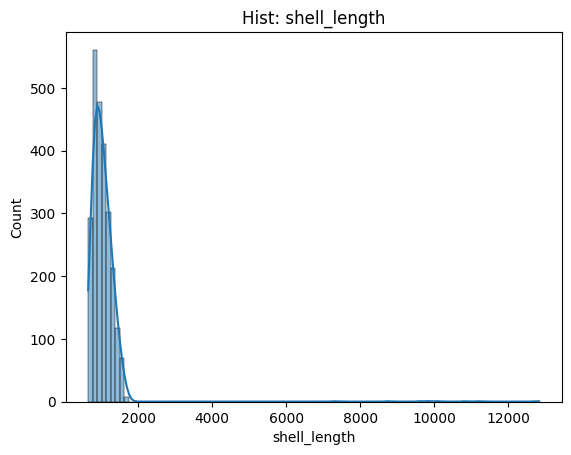

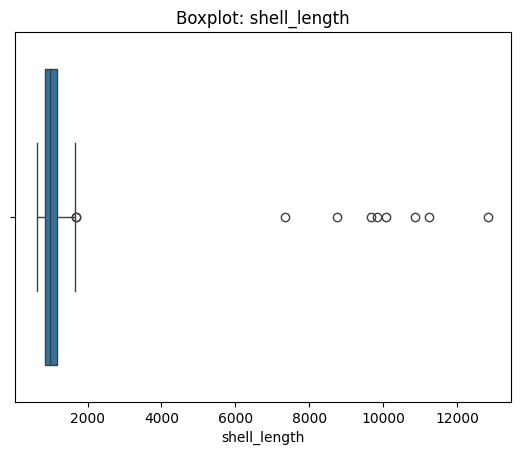

count     2486.000000
mean       945.018101
std        507.521189
min        564.000000
25%        752.250000
50%        889.000000
75%       1056.000000
max      11550.000000
Name: shell_width, dtype: float64
Выбросы:
Количество: 11
Процент: 0.44
Границы: 296.62 1511.62
Первые 5 выбросов выше верхней границы [1521 1551 1554 6230 7750]
5 максимальных значений [ 8780  9150  9710 10120 11550]


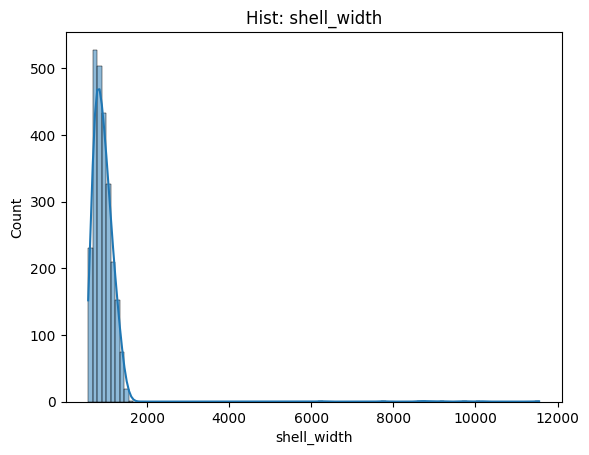

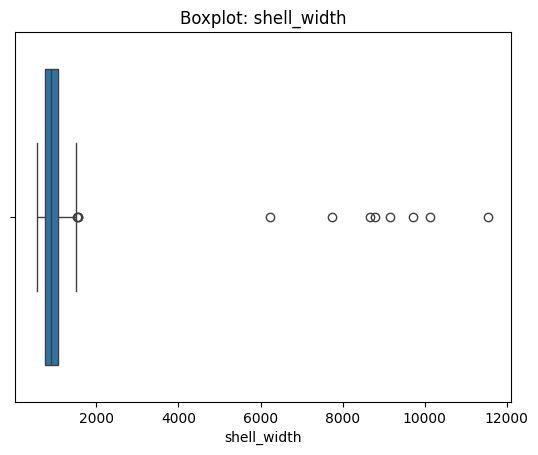

count    2451.000000
mean      169.723378
std        41.335454
min        87.000000
25%       138.000000
50%       163.000000
75%       195.000000
max       328.000000
Name: head_length, dtype: float64
Выбросы:
Количество: 20
Процент: 0.82
Границы: 52.5 280.5
Первые 5 выбросов выше верхней границы [281. 281. 281. 282. 283.]
5 максимальных значений [304. 312. 318. 321. 328.]


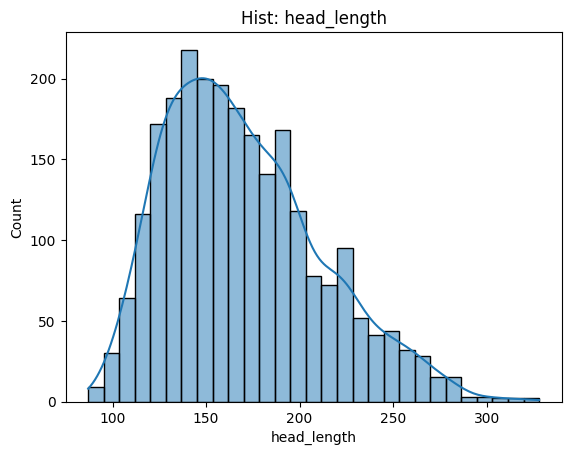

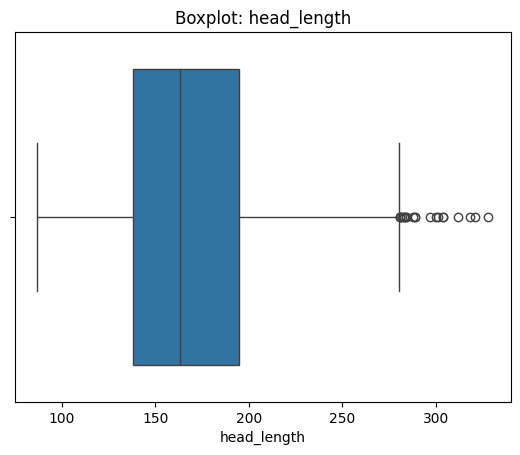

count    2451.000000
mean      183.321093
std        45.477540
min        96.000000
25%       148.000000
50%       176.000000
75%       212.000000
max       382.000000
Name: head_width, dtype: float64
Выбросы:
Количество: 17
Процент: 0.69
Границы: 52.0 308.0
Первые 5 выбросов выше верхней границы [311. 311. 311. 311. 313.]
5 максимальных значений [348. 352. 353. 364. 382.]


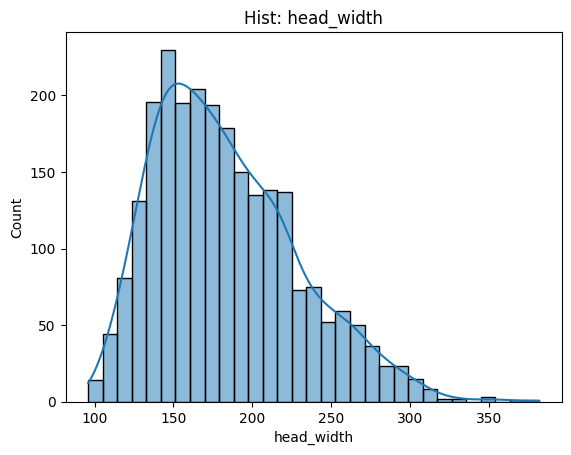

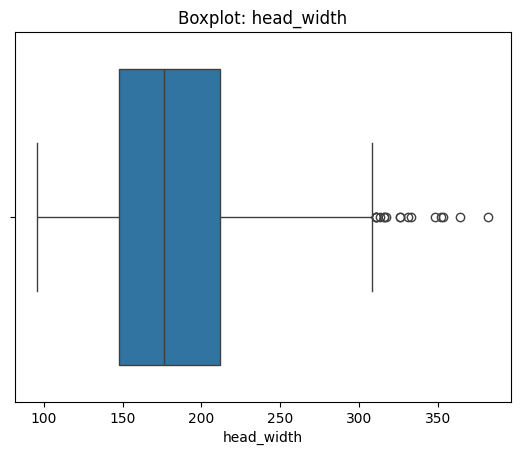

count    2486.000000
mean      612.010459
std       142.589526
min       339.000000
25%       502.000000
50%       587.000000
75%       702.000000
max      1147.000000
Name: flipper_length_1, dtype: float64
Выбросы:
Количество: 14
Процент: 0.56
Границы: 202.0 1002.0
Первые 5 выбросов выше верхней границы [1003 1003 1008 1010 1011]
5 максимальных значений [1047 1058 1058 1118 1147]


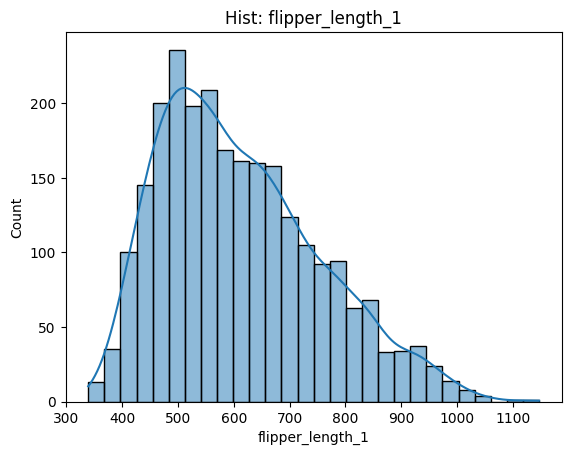

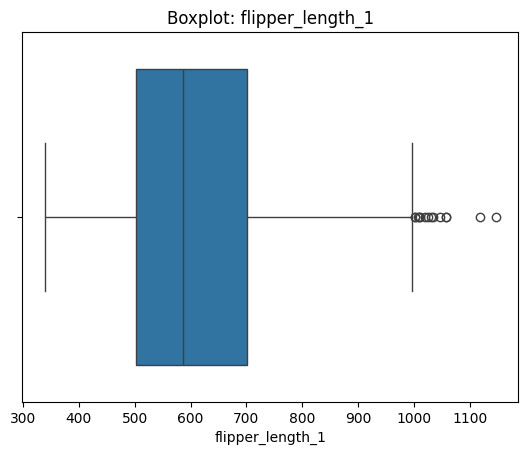

count    2486.000000
mean      549.364441
std       131.859104
min       245.000000
25%       449.000000
50%       527.000000
75%       632.000000
max      1072.000000
Name: flipper_width_1, dtype: float64
Выбросы:
Количество: 22
Процент: 0.88
Границы: 174.5 906.5
Первые 5 выбросов выше верхней границы [912 916 918 921 923]
5 максимальных значений [ 997 1003 1011 1023 1072]


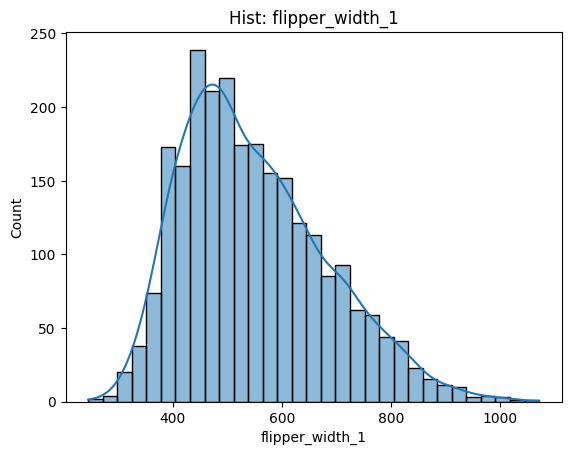

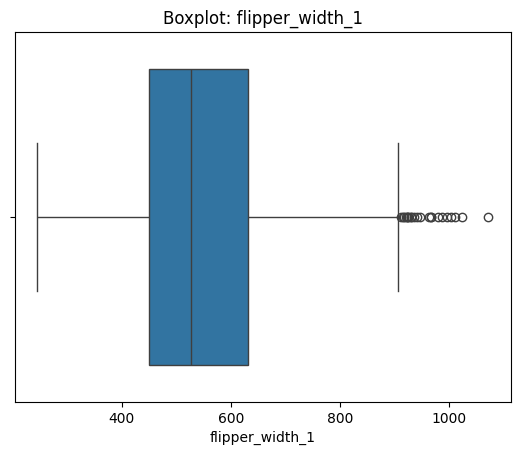

count    2486.000000
mean      611.890185
std       138.991986
min       327.000000
25%       505.000000
50%       591.000000
75%       704.000000
max      1049.000000
Name: flipper_length_2, dtype: float64
Выбросы:
Количество: 12
Процент: 0.48
Границы: 206.5 1002.5
Первые 5 выбросов выше верхней границы [1004 1005 1007 1009 1010]
5 максимальных значений [1019 1022 1032 1045 1049]


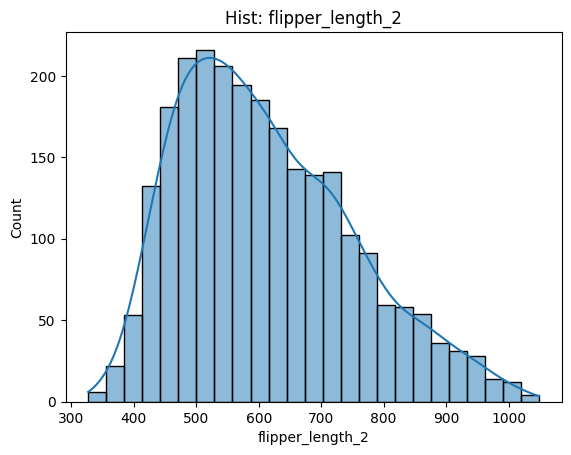

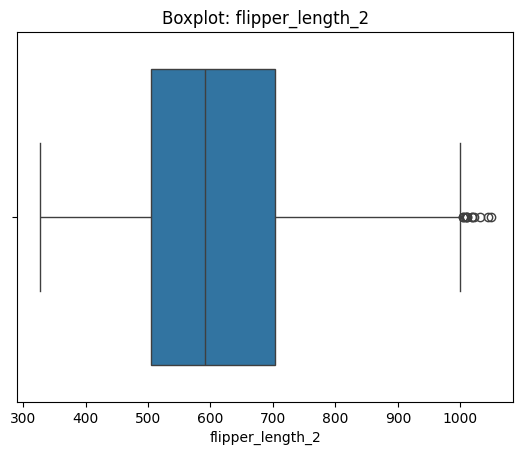

count    2486.000000
mean      550.253017
std       130.856316
min       276.000000
25%       449.000000
50%       533.000000
75%       635.000000
max       997.000000
Name: flipper_width_2, dtype: float64
Выбросы:
Количество: 15
Процент: 0.6
Границы: 170.0 914.0
Первые 5 выбросов выше верхней границы [917 917 918 923 925]
5 максимальных значений [969 975 978 995 997]


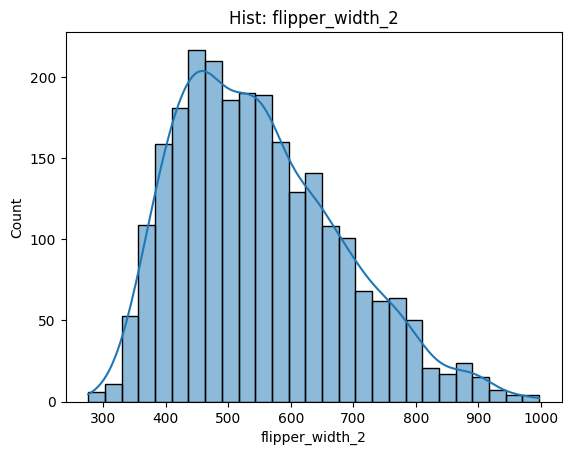

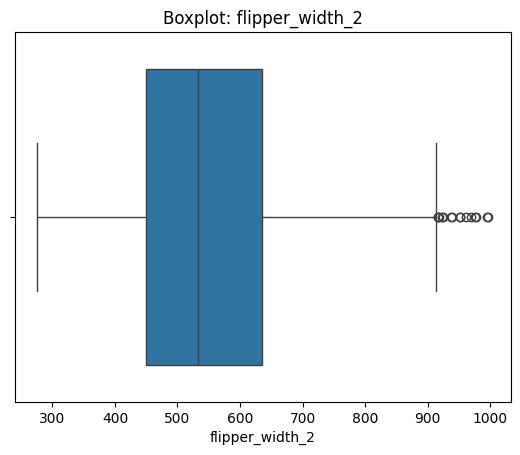

count    2457.000000
mean      487.262922
std       110.435270
min       282.000000
25%       400.000000
50%       473.000000
75%       558.000000
max       934.000000
Name: flipper_length_3, dtype: float64
Выбросы:
Количество: 12
Процент: 0.49
Границы: 163.0 795.0
Первые 5 выбросов выше верхней границы [798. 800. 805. 815. 821.]
5 максимальных значений [830. 831. 837. 857. 934.]


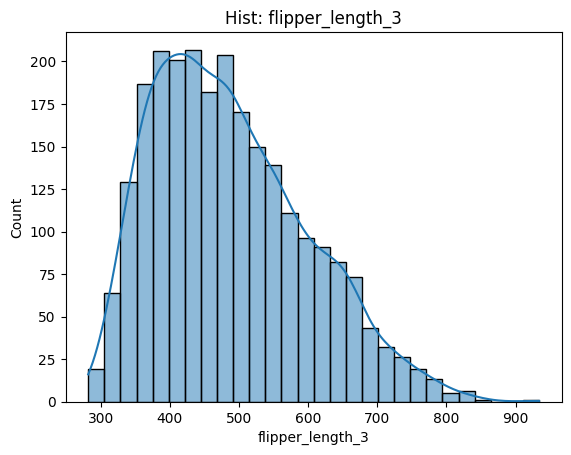

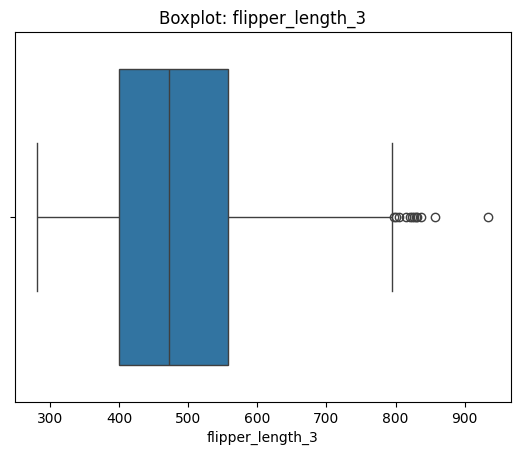

count    2457.000000
mean      440.667481
std       105.532073
min       231.000000
25%       357.000000
50%       425.000000
75%       511.000000
max       837.000000
Name: flipper_width_3, dtype: float64
Выбросы:
Количество: 17
Процент: 0.69
Границы: 126.0 742.0
Первые 5 выбросов выше верхней границы [745. 747. 750. 756. 758.]
5 максимальных значений [777. 777. 819. 833. 837.]


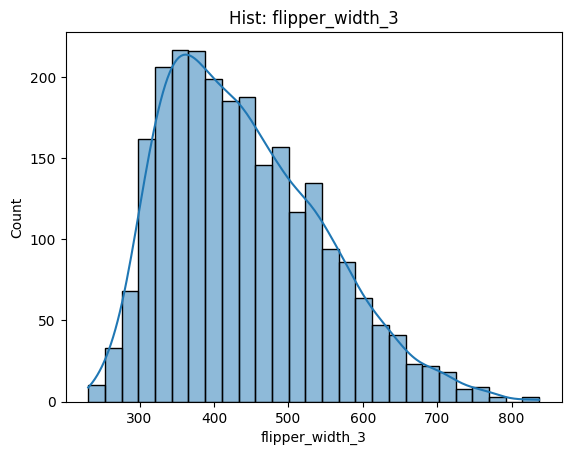

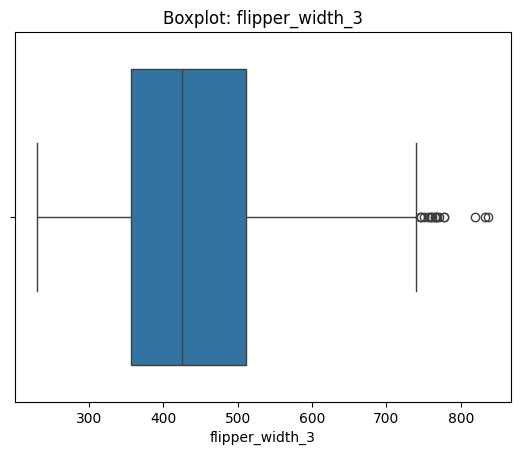

count    2457.000000
mean      489.176231
std       112.562973
min       254.000000
25%       400.000000
50%       473.000000
75%       563.000000
max       877.000000
Name: flipper_length_4, dtype: float64
Выбросы:
Количество: 13
Процент: 0.53
Границы: 155.5 807.5
Первые 5 выбросов выше верхней границы [809. 817. 818. 820. 823.]
5 максимальных значений [844. 845. 855. 868. 877.]


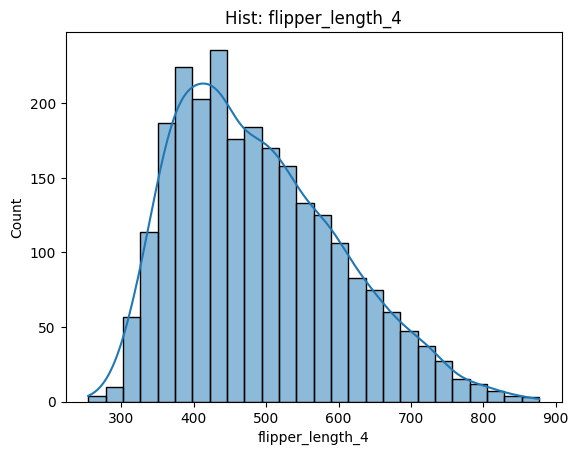

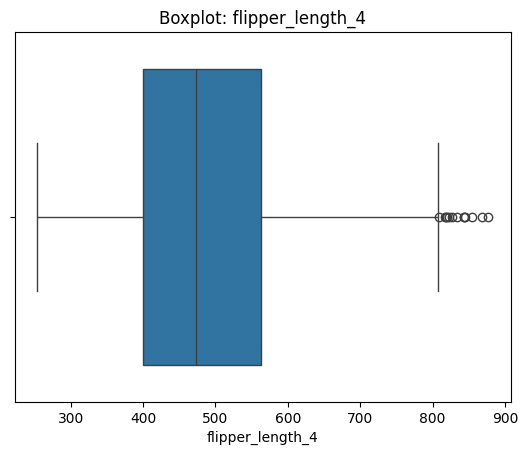

count    2457.000000
mean      440.975173
std       104.573836
min       243.000000
25%       359.000000
50%       423.000000
75%       509.000000
max       806.000000
Name: flipper_width_4, dtype: float64
Выбросы:
Количество: 16
Процент: 0.65
Границы: 134.0 734.0
Первые 5 выбросов выше верхней границы [735. 736. 739. 741. 748.]
5 максимальных значений [764. 772. 785. 790. 806.]


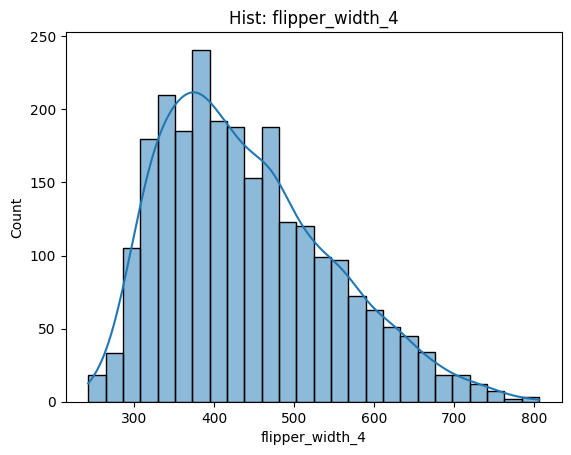

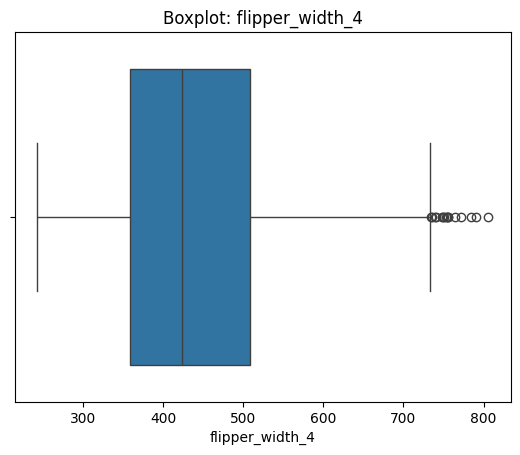

count    2486.000000
mean       80.931617
std        16.228851
min        29.000000
25%        70.000000
50%        80.000000
75%        91.000000
max       143.000000
Name: circle_count, dtype: float64
Выбросы:
Количество: 32
Процент: 1.29
Границы: 38.5 122.5
Первые 5 выбросов выше верхней границы [123 123 123 123 124]
5 максимальных значений [137 138 139 141 143]


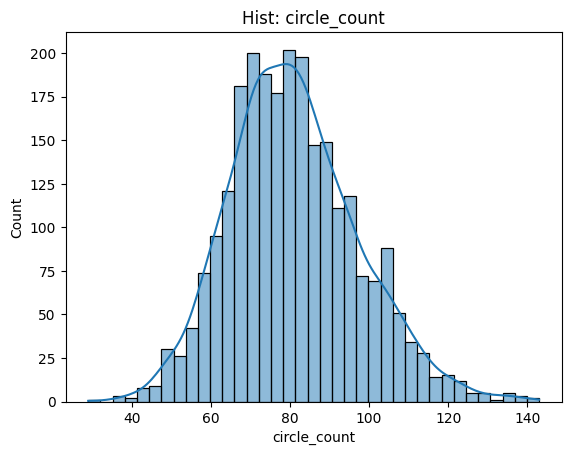

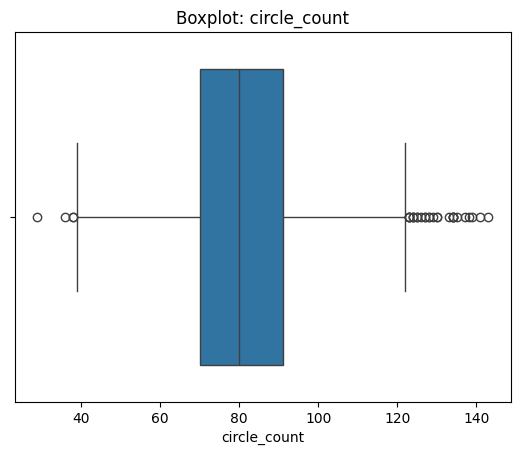

count    2486.000000
mean       96.068853
std        35.149431
min         0.000000
25%        67.500750
50%        87.900000
75%       117.629500
max       199.961000
Name: weight, dtype: float64
Выбросы:
Количество: 15
Процент: 0.6
Границы: -7.69 192.82
Первые 5 выбросов выше верхней границы [192.833 193.17  193.852 194.846 194.899]
5 максимальных значений [197.681 197.696 197.775 197.905 199.961]


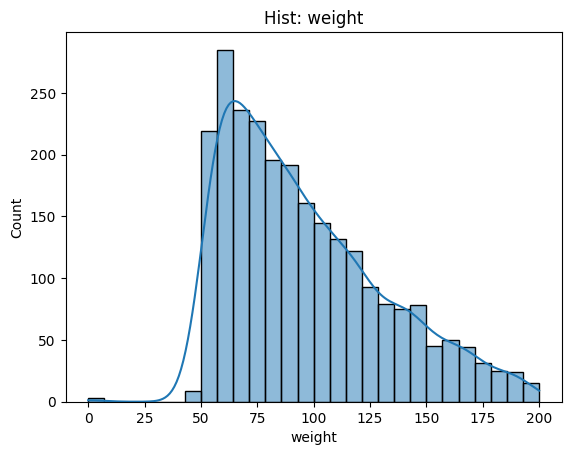

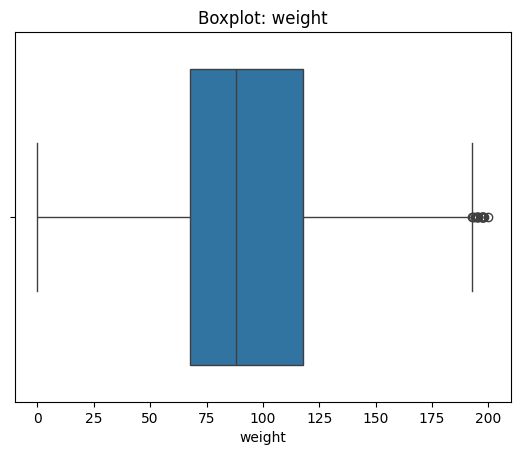

In [12]:
def data_review(df, col):
    data = df[col].dropna()
    print(data.describe())
    
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    high_outliers = data[data > upper_bound].sort_values(ascending=True)
    
    print("Выбросы:")
    print("Количество:", len(outliers))
    print("Процент:", round(len(outliers)/len(data)*100, 2))
    print("Границы:", round(lower_bound, 2), round(upper_bound, 2))
    print("Первые 5 выбросов выше верхней границы", high_outliers.head(5).values)
    print("5 максимальных значений", high_outliers.tail(5).values)
    sns.histplot(data, kde=True)
    plt.title(f"Hist: {col}")
    plt.show()

    sns.boxplot(x=data)
    plt.title(f"Boxplot: {col}")
    plt.show()
cols = ['shell_length', 'shell_width', 'head_length', 'head_width', 'flipper_length_1', 
        'flipper_width_1', 'flipper_length_2', 'flipper_width_2', 'flipper_length_3', 
        'flipper_width_3', 'flipper_length_4', 'flipper_width_4', 'circle_count', 'weight']
for col in cols:
    data_review(data, col)

- Признаки размеров имеют равномерное распределения с правым хвостом с редкими выбросами.
- Часть очень больших значений вероятно является ошибкой масштаба *10, поэтому они корректируются через попадание в границы IQR при делении на 10
- Признак колец имеет равномерное распределение, что соответствует росту возраста черепах, малые значения соответствуют молодым особям.
- Есть особи с весом 0 нужно проверить сколько их, и как выглядят эти объекты  

count    2457.000000
mean     1018.436304
std       222.149470
min       645.000000
25%       837.000000
50%       979.000000
75%      1168.000000
max      1683.000000
Name: shell_length, dtype: float64
Выбросы:
Количество: 3
Процент: 0.12
Границы: 340.5 1664.5
Первые 5 выбросов выше верхней границы [1667. 1680. 1683.]
5 максимальных значений [1667. 1680. 1683.]


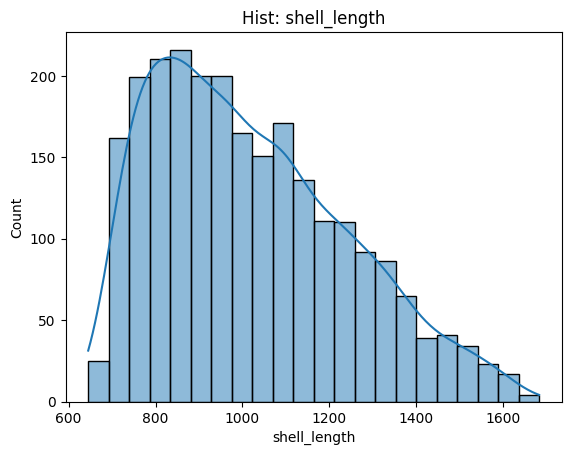

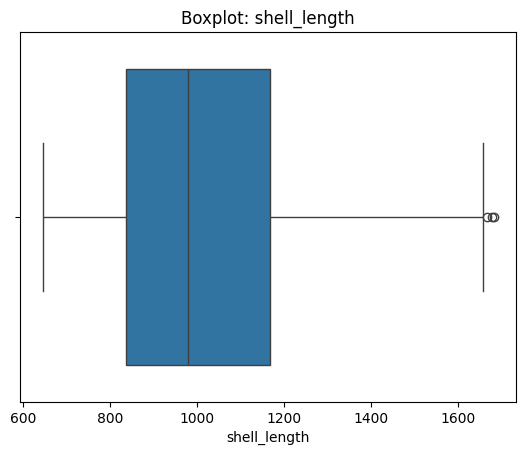

count    2486.000000
mean      918.970233
std       203.241558
min       564.000000
25%       752.000000
50%       887.000000
75%      1054.000000
max      1554.000000
Name: shell_width, dtype: float64
Выбросы:
Количество: 4
Процент: 0.16
Границы: 299.0 1507.0
Первые 5 выбросов выше верхней границы [1510. 1521. 1551. 1554.]
5 максимальных значений [1510. 1521. 1551. 1554.]


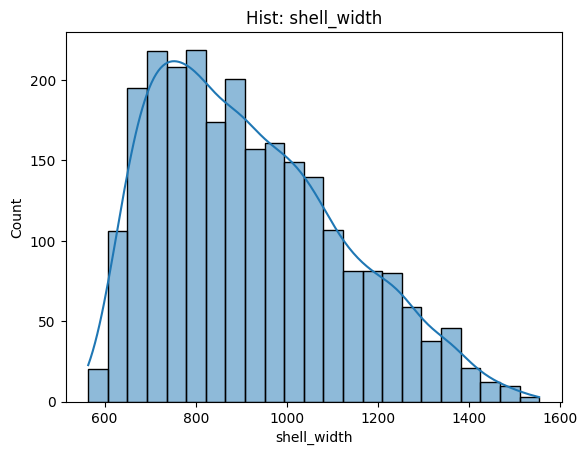

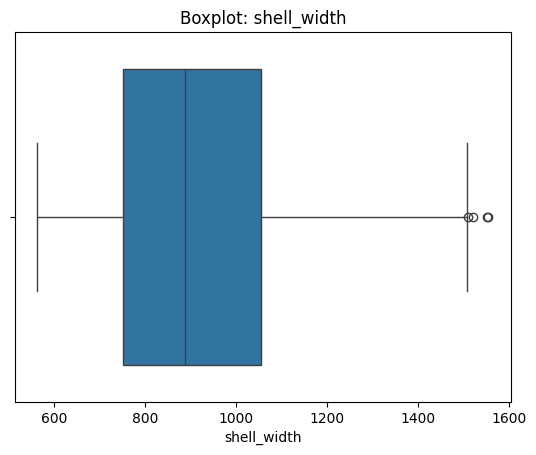

count    2451.000000
mean      169.723378
std        41.335454
min        87.000000
25%       138.000000
50%       163.000000
75%       195.000000
max       328.000000
Name: head_length, dtype: float64
Выбросы:
Количество: 20
Процент: 0.82
Границы: 52.5 280.5
Первые 5 выбросов выше верхней границы [281. 281. 281. 282. 283.]
5 максимальных значений [304. 312. 318. 321. 328.]


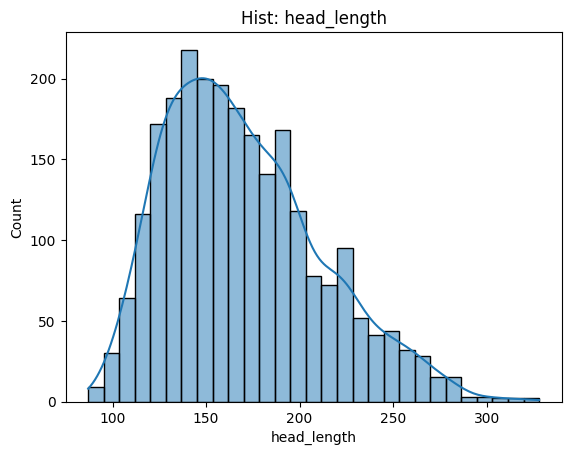

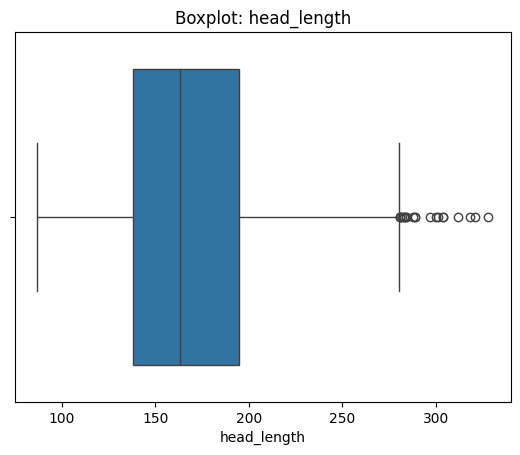

count    2451.000000
mean      183.321093
std        45.477540
min        96.000000
25%       148.000000
50%       176.000000
75%       212.000000
max       382.000000
Name: head_width, dtype: float64
Выбросы:
Количество: 17
Процент: 0.69
Границы: 52.0 308.0
Первые 5 выбросов выше верхней границы [311. 311. 311. 311. 313.]
5 максимальных значений [348. 352. 353. 364. 382.]


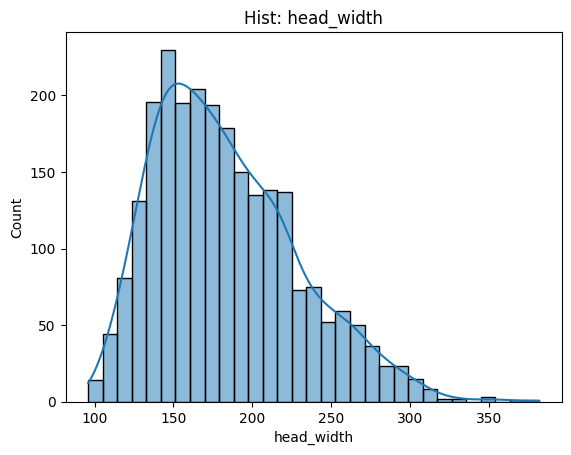

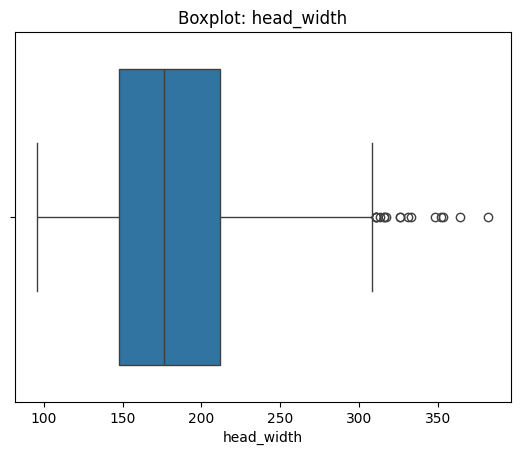

count    2486.000000
mean      612.010459
std       142.589526
min       339.000000
25%       502.000000
50%       587.000000
75%       702.000000
max      1147.000000
Name: flipper_length_1, dtype: float64
Выбросы:
Количество: 14
Процент: 0.56
Границы: 202.0 1002.0
Первые 5 выбросов выше верхней границы [1003. 1003. 1008. 1010. 1011.]
5 максимальных значений [1047. 1058. 1058. 1118. 1147.]


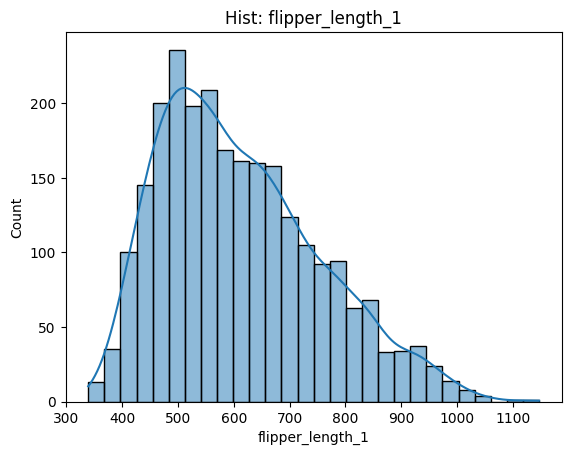

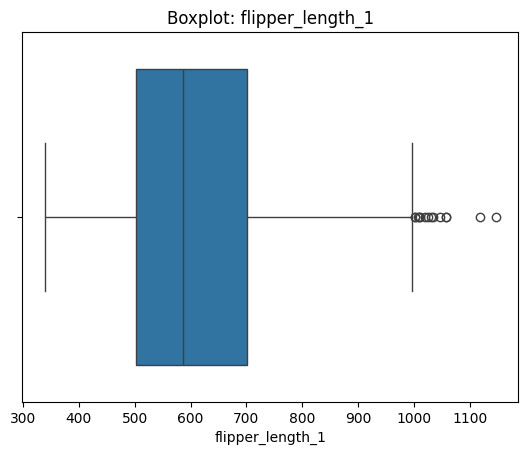

count    2486.000000
mean      549.364441
std       131.859104
min       245.000000
25%       449.000000
50%       527.000000
75%       632.000000
max      1072.000000
Name: flipper_width_1, dtype: float64
Выбросы:
Количество: 22
Процент: 0.88
Границы: 174.5 906.5
Первые 5 выбросов выше верхней границы [912. 916. 918. 921. 923.]
5 максимальных значений [ 997. 1003. 1011. 1023. 1072.]


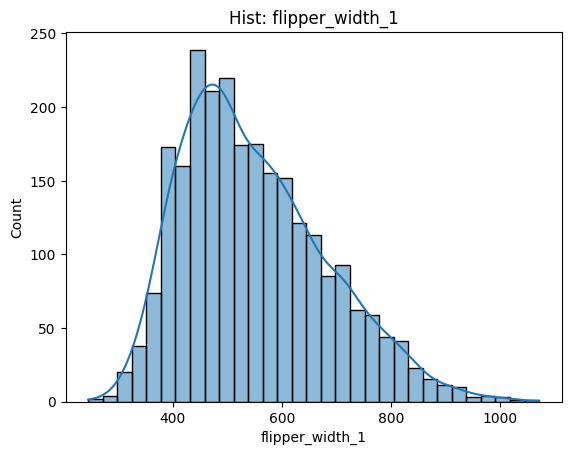

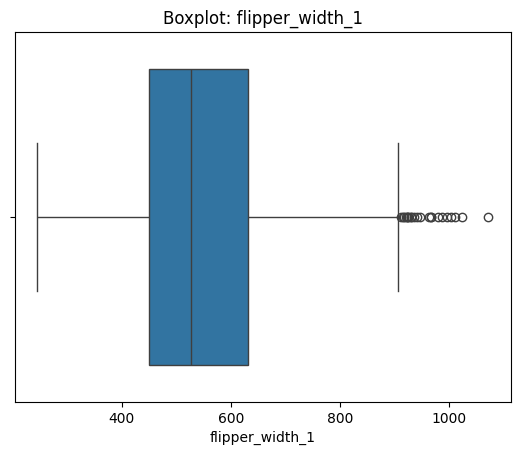

count    2486.000000
mean      611.890185
std       138.991986
min       327.000000
25%       505.000000
50%       591.000000
75%       704.000000
max      1049.000000
Name: flipper_length_2, dtype: float64
Выбросы:
Количество: 12
Процент: 0.48
Границы: 206.5 1002.5
Первые 5 выбросов выше верхней границы [1004. 1005. 1007. 1009. 1010.]
5 максимальных значений [1019. 1022. 1032. 1045. 1049.]


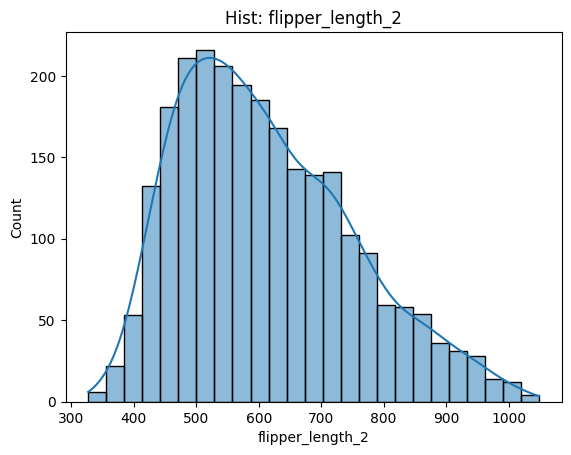

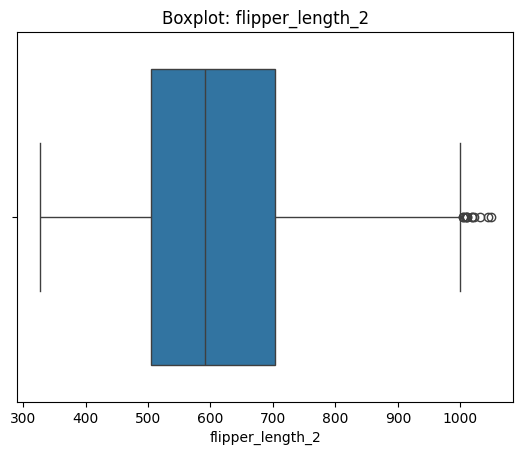

count    2486.000000
mean      550.253017
std       130.856316
min       276.000000
25%       449.000000
50%       533.000000
75%       635.000000
max       997.000000
Name: flipper_width_2, dtype: float64
Выбросы:
Количество: 15
Процент: 0.6
Границы: 170.0 914.0
Первые 5 выбросов выше верхней границы [917. 917. 918. 923. 925.]
5 максимальных значений [969. 975. 978. 995. 997.]


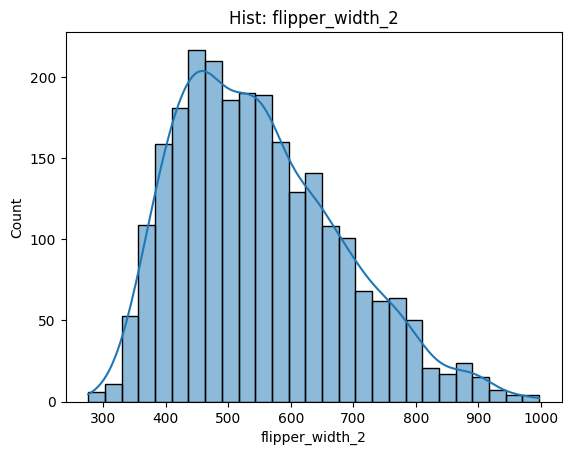

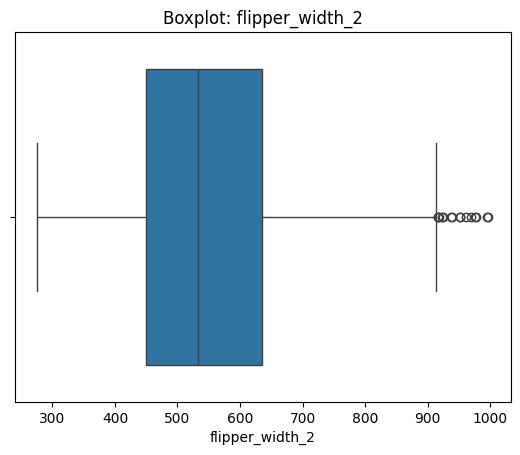

count    2457.000000
mean      487.262922
std       110.435270
min       282.000000
25%       400.000000
50%       473.000000
75%       558.000000
max       934.000000
Name: flipper_length_3, dtype: float64
Выбросы:
Количество: 12
Процент: 0.49
Границы: 163.0 795.0
Первые 5 выбросов выше верхней границы [798. 800. 805. 815. 821.]
5 максимальных значений [830. 831. 837. 857. 934.]


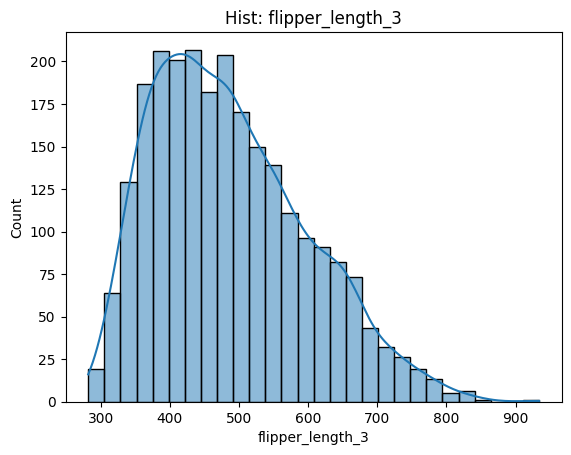

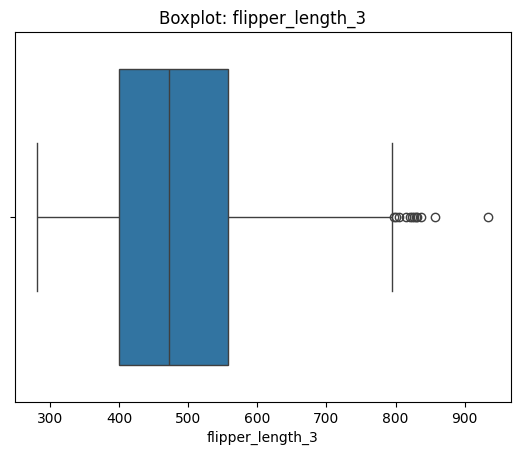

count    2457.000000
mean      440.667481
std       105.532073
min       231.000000
25%       357.000000
50%       425.000000
75%       511.000000
max       837.000000
Name: flipper_width_3, dtype: float64
Выбросы:
Количество: 17
Процент: 0.69
Границы: 126.0 742.0
Первые 5 выбросов выше верхней границы [745. 747. 750. 756. 758.]
5 максимальных значений [777. 777. 819. 833. 837.]


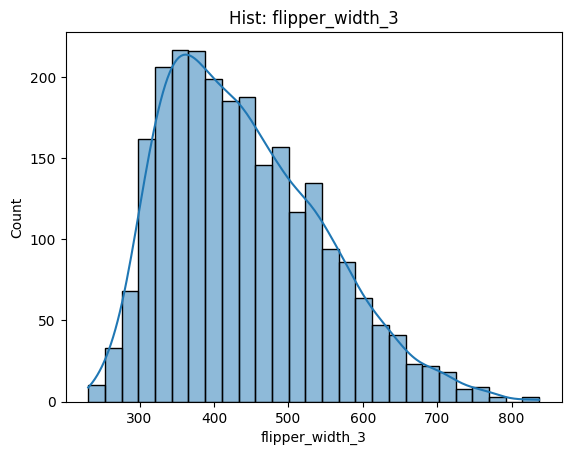

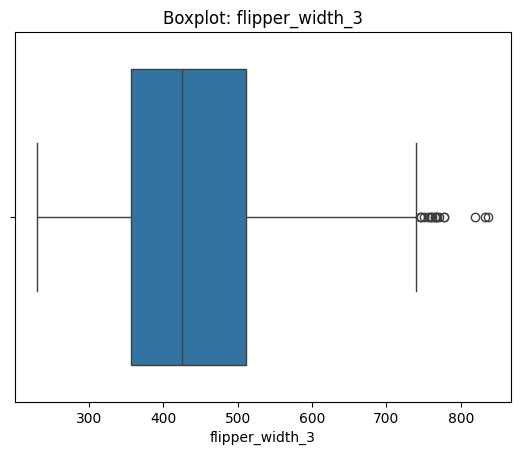

count    2457.000000
mean      489.176231
std       112.562973
min       254.000000
25%       400.000000
50%       473.000000
75%       563.000000
max       877.000000
Name: flipper_length_4, dtype: float64
Выбросы:
Количество: 13
Процент: 0.53
Границы: 155.5 807.5
Первые 5 выбросов выше верхней границы [809. 817. 818. 820. 823.]
5 максимальных значений [844. 845. 855. 868. 877.]


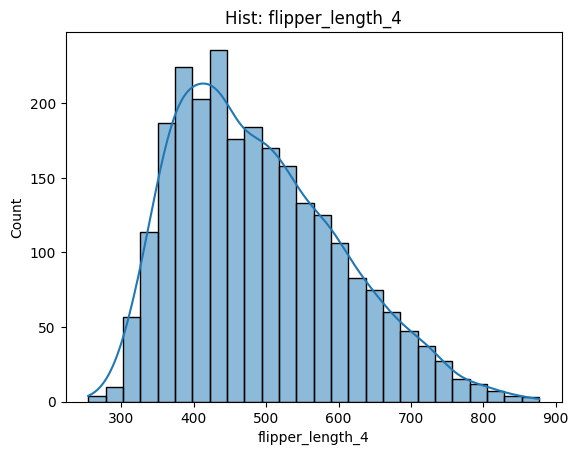

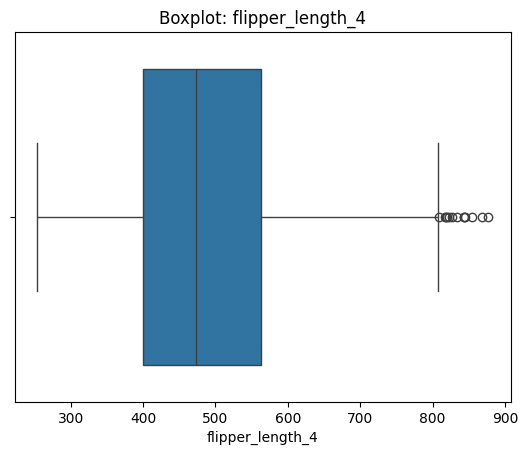

count    2457.000000
mean      440.975173
std       104.573836
min       243.000000
25%       359.000000
50%       423.000000
75%       509.000000
max       806.000000
Name: flipper_width_4, dtype: float64
Выбросы:
Количество: 16
Процент: 0.65
Границы: 134.0 734.0
Первые 5 выбросов выше верхней границы [735. 736. 739. 741. 748.]
5 максимальных значений [764. 772. 785. 790. 806.]


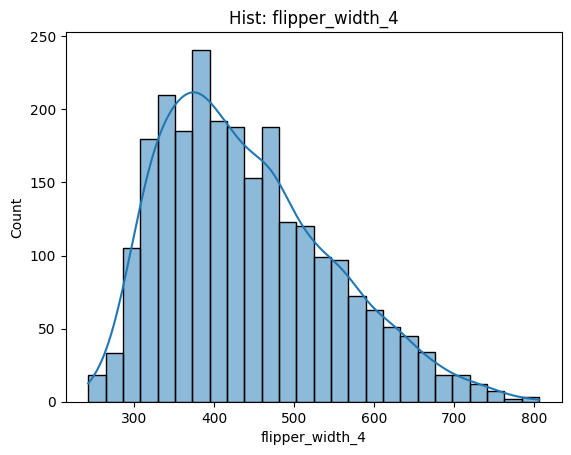

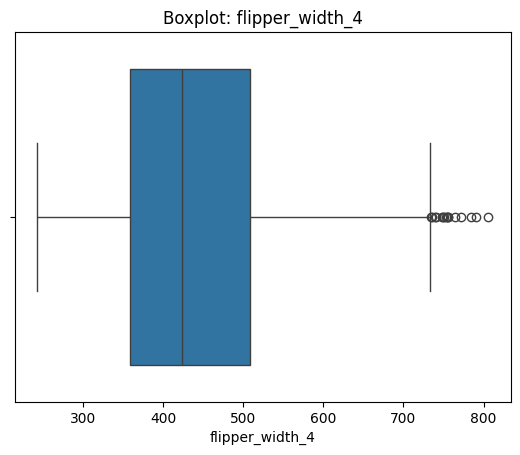

In [13]:
cols = ['shell_length', 'shell_width', 'head_length', 'head_width', 'flipper_length_1', 
        'flipper_width_1', 'flipper_length_2', 'flipper_width_2', 'flipper_length_3', 
        'flipper_width_3', 'flipper_length_4', 'flipper_width_4']
for col in cols: 
    q1 = data[col].quantile(0.25) 
    q3 = data[col].quantile(0.75) 
    iqr = q3 - q1 
    lower = q1 - 1.5 * iqr 
    upper = q3 + 1.5 * iqr 
    mask = (data[col] > upper) & ((data[col] / 10 >= lower) & (data[col] / 10 <= upper)) 
    data[col] = data[col].astype(float) 
    data.loc[mask, col] = data.loc[mask, col] / 10
for col in cols:
    data_review(data, col)

In [14]:
data.sort_values('weight').head(10)

,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,shell_crack,weight
5004,892.0,826.0,124.0,158.0,543.0,482.0,517.0,528.0,431.0,442.0,448.0,377.0,83,0.0,0.000
3185,780.0,797.0,145.0,150.0,539.0,426.0,536.0,513.0,399.0,388.0,361.0,369.0,70,0.0,0.000
809,1506.0,1341.0,262.0,265.0,979.0,777.0,910.0,732.0,728.0,651.0,604.0,676.0,109,0.0,0.000
7375,702.0,659.0,121.0,113.0,395.0,334.0,444.0,442.0,373.0,304.0,321.0,308.0,65,1.0,49.045
7655,686.0,616.0,112.0,123.0,396.0,435.0,431.0,358.0,321.0,291.0,280.0,322.0,66,0.0,49.230
660,704.0,702.0,133.0,119.0,440.0,436.0,388.0,448.0,359.0,290.0,299.0,303.0,75,0.0,49.440
394,679.0,660.0,154.0,109.0,400.0,358.0,410.0,402.0,297.0,324.0,355.0,273.0,84,0.0,49.483
1487,671.0,625.0,118.0,113.0,451.0,348.0,415.0,346.0,319.0,315.0,384.0,308.0,59,0.0,49.558
1512,697.0,624.0,105.0,145.0,370.0,398.0,344.0,343.0,382.0,288.0,344.0,351.0,69,0.0,49.572
2449,NaN,637.0,135.0,127.0,496.0,323.0,459.0,377.0,320.0,301.0,334.0,314.0,83,0.0,49.719


Найдено 3 особи с весом 0, возможно это означает нет иформации о весе

In [15]:
data.loc[data['weight'] == 0, 'weight'] = np.nan
print("Количество нулей после замены:", (data['weight'] == 0).sum())
data = data.dropna(subset=['weight'])

Количество нулей после замены: 0


В данных признаки обладают разным масштабом (например, circle_count и shell_length). Это может негативно влиять на обучение модели линейной регрессии, так как модель чувствительна к масштабу признаков. При этом распределения признаков нормальное, а доля выбросов невелика (в среднем около 0.6%), поэтому сильного влияния экстремальных значений не наблюдается. В связи с этим для приведения признаков к единому масштабу будет использоваться StandardScaler, так как он хорошо подходит для линейной регрессии и корректно работает при небольшом количестве выбросов.

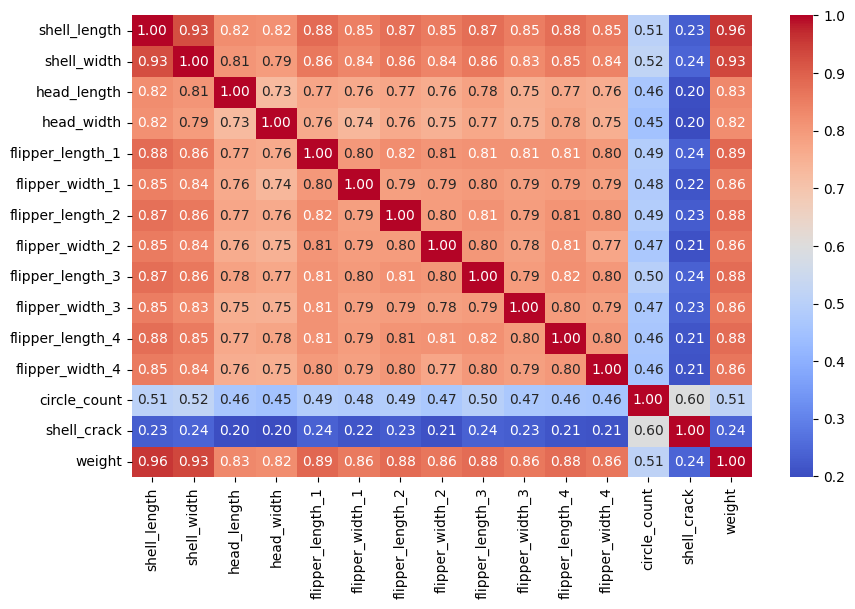

In [16]:
interval_cols = data.select_dtypes(include=['number']).columns.tolist()
phik_corr = data.phik_matrix(interval_cols=interval_cols)
plt.figure(figsize=(10, 6))
sns.heatmap(phik_corr, cmap='coolwarm', annot=True, fmt=".2f")
plt.show()

Между признаками обнаружена мультиколлинеарность, она объясняется природой данных, так как все признаки описывают размеры одного вида черепахи.
Это подтверждается высокими значениями Phik-корреляции, например:

- размеры панциря сильно связаны между собой и с целевой переменной:
shell_length и weight: 0.96 
shell_width и weight: 0.93
shell_length и shell_width: 0.93
- признаки ласт образуют группу с корреляциями:
flipper_length_n и flipper_width_n: в диапазоне ≈ 0.77–0.82
- признаки головы также зависимы:
head_length и head_width — ≈ 0.73
- признаки ласт сильно коллирируют с размером панциря
#### Вывод

Для построения модели важно учитывать мультиколлинеарность:
- либо удалить избыточные признаки внутри групп;
- либо использовать методы регуляризации, которые уменьшают влияние коррелирующих признаков.

Необходимо создать список признаков без мультиколлиниарности

In [17]:
cols_no_coll = ['shell_length', 'head_length', 'flipper_length_1', 'shell_crack', 'circle_count']

## Предобработка данных

- Разделим данные на выборки: обучающую (60%), валидационную (20%) и тестовую (20%). 
- Обработаем пропуски. Напишем фунцию для заполнения их медианной. Рассчитаем заполнитель только по обучающей выборке.
- Напишим функцию для стандартизации признаков. Расчёт параметров масштабирования делаем только по обучающей выборке
- Напишите функцию для нормализации признаков.

In [18]:
def scale_features(X_train, X_val, X_test, method):
    if method == 'norm':
        trn_min = X_train.min()
        trn_max = X_train.max()
        X_train_scaled = (X_train - trn_min) / (trn_max - trn_min)
        X_val_scaled = (X_val - trn_min) / (trn_max - trn_min)
        X_test_scaled = (X_test - trn_min) / (trn_max - trn_min)
    elif method == 'stand':
        trn_mean = X_train.mean()
        trn_std  = X_train.std()
        X_train_scaled = (X_train - trn_mean) / trn_std
        X_val_scaled = (X_val - trn_mean) / trn_std
        X_test_scaled = (X_test - trn_mean) / trn_std
    return X_train_scaled, X_val_scaled, X_test_scaled
    
def fill_na_median(X_train, X_val, X_test):
    features_with_na = X_train.columns[X_train.isnull().any()].tolist()
    medians = X_train[features_with_na].median()
    X_train_filled = X_train.fillna(medians)
    X_val_filled = X_val.fillna(medians)
    X_test_filled = X_test.fillna(medians)
    return X_train_filled, X_val_filled, X_test_filled

Создадим 2 функции scale_features для нормальизации и fill_na_median для заполнения пропусков

In [19]:
def prepare_data(data, missing, scaling, coll, target):
    if coll == 'no_coll':
        X = data[cols_no_coll].copy()
    else:
        X = data.drop(columns=[target]).copy()
    y = data[target].copy()
    
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
    if missing == 'dropna':
        train_idx = X_train.dropna().index
        val_idx = X_val.dropna().index
        test_idx = X_test.dropna().index
        X_train, y_train = X_train.loc[train_idx], y_train.loc[train_idx]
        X_val, y_val = X_val.loc[val_idx], y_val.loc[val_idx]
        X_test, y_test = X_test.loc[test_idx], y_test.loc[test_idx]

    elif missing == 'fill_med':
        X_train, X_val, X_test = fill_na_median(X_train, X_val, X_test)
    if scaling != 'no_scal':
        X_train, X_val, X_test = scale_features(X_train, X_val, X_test, scaling)
    return X_train, X_val, X_test, y_train, y_val, y_test

#### Подготовим функцию обработки датасета по 3 параметрам:
- включаем коллиниарность или нет
- как обрабатываем пропуски
- масштабируем ли признаки и если да то как

## Обучение моделей

- Построим базовую модель (дамми), с которой будете сравнивать все остальные. Если они будут хуже базовой по качеству, это будет означать, что при обучении что-то пошло не так. 
- Обучим несколько архитектур линейных моделей. Они могут различаться по ряду черт: набором отобранных признаков, масштабом признаков, установленными гиперпараметрами, функциями потерь. Попробуем обучить следующие модели:
   - `LinearRegression`;
   - `Lasso` (L1-регуляризация);
   - `Ridge` (L2-регуляризация);
   - `SGDRegressor`.
- Сформируем итоговую таблицу с результатами моделей. Это удобно сделать в виде датафрейма pandas.

In [20]:
def calc_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, mse, mape, r2


def model_test(model, model_name, data, target):
    results = []
    for missing in ['fill_med', 'dropna']:
        for scaling in ['no_scal', 'norm', 'stand']:
            for coll in ['with_coll', 'no_coll']:
                X_train, X_val, X_test, y_train, y_val, y_test = prepare_data(data, missing, scaling, coll, target)
                model.fit(X_train, y_train)
                train_mae, train_mse, train_mape, train_r2 = calc_metrics(y_train, model.predict(X_train))
                val_mae, val_mse, val_mape, val_r2 = calc_metrics(y_val, model.predict(X_val))
                ds_name = f"{missing}+{scaling}+{coll}"
                results.append({
                    "name": model_name,
                    "ds_name": ds_name,
                    "train_MAE": train_mae,
                    "train_MSE": train_mse,
                    "train_MAPE": train_mape,
                    "train_R2": train_r2,
                    "val_MAE": val_mae,
                    "val_MSE": val_mse,
                    "val_MAPE": val_mape,
                    "val_R2": val_r2,})
    return results

In [21]:
models = [
    ("Dummy", DummyRegressor, [
        {"strategy": "mean"},
    ]),

    ("LinReg", LinearRegression, [
        {},
    ]),

    ("Lasso", Lasso, [
        {"alpha": 0.001},
        {"alpha": 0.01},
        {"alpha": 0.1},
        {"alpha": 1.0},
    ]),

    ("Rid", Ridge, [
        {"alpha": 0.001, "max_iter": 1000},
        {"alpha": 0.01,  "max_iter": 1000},
        {"alpha": 0.1,   "max_iter": 1000},
        {"alpha": 1.0,   "max_iter": 1000},
    ]),

    ("SGD", SGDRegressor, [
        {"alpha": 0.0001, "learning_rate": "invscaling", "random_state": 42},
        {"alpha": 0.001,  "learning_rate": "invscaling", "random_state": 42},
        {"alpha": 0.01,   "learning_rate": "invscaling", "random_state": 42},
        {"alpha": 0.0001, "learning_rate": "optimal",    "random_state": 42},
    ]),
]
all_results = []

for model_name, ModelClass, param_list in models:
    for params in param_list:
        model = ModelClass(**params)
        name = f"{model_name} {params}"
        res = model_test(model, name, data, 'weight')
        all_results.extend(res)
df_results = pd.DataFrame(all_results)
best_res = df_results[
  (
    (df_results['val_R2'] >= 0.90) &
    (df_results['val_MAE'] <= 5) &
    ((df_results['train_R2'] - df_results['val_R2']).abs() < 0.1)
  ) |
  (df_results['name'] == "Dummy {'strategy': 'mean'}")
].sort_values('val_MAE').reset_index(drop=True)

pd.set_option('display.float_format', '{:.6f}'.format)
with pd.option_context('display.max_rows', None):display(best_res)
print(best_res)

,name,ds_name,train_MAE,train_MSE,train_MAPE,train_R2,val_MAE,val_MSE,val_MAPE,val_R2
0,Lasso {'alpha': 0.1},dropna+stand+with_coll,3.474512,20.304690,3.844039,0.983687,3.883510,24.615637,4.182323,0.978172
1,Lasso {'alpha': 1.0},dropna+stand+with_coll,3.501998,21.674294,3.725145,0.982587,3.885862,26.030220,4.051062,0.976918
2,Lasso {'alpha': 1.0},dropna+no_scal+with_coll,3.481901,20.297404,3.868915,0.983693,3.889793,24.548310,4.202193,0.978232
3,Lasso {'alpha': 0.01},dropna+norm+with_coll,3.477679,20.287171,3.856256,0.983701,3.891246,24.637016,4.197150,0.978154
4,Lasso {'alpha': 0.1},dropna+no_scal+with_coll,3.482816,20.285648,3.870641,0.983702,3.893472,24.611539,4.208569,0.978176
5,Lasso {'alpha': 0.01},dropna+stand+with_coll,3.481301,20.272480,3.867175,0.983713,3.896818,24.669205,4.210174,0.978125
6,Lasso {'alpha': 0.001},dropna+norm+with_coll,3.481648,20.272273,3.868237,0.983713,3.897268,24.667195,4.210854,0.978127
7,Lasso {'alpha': 0.01},dropna+no_scal+with_coll,3.482208,20.272204,3.869805,0.983713,3.897554,24.666314,4.212236,0.978128
8,Lasso {'alpha': 0.001},dropna+stand+with_coll,3.482163,20.272077,3.869616,0.983713,3.897985,24.672421,4.212402,0.978122
9,Lasso {'alpha': 0.001},dropna+no_scal+with_coll,3.482222,20.272070,3.869814,0.983713,3.898090,24.672991,4.212682,0.978122


                           name                   ds_name  train_MAE  \
0          Lasso {'alpha': 0.1}    dropna+stand+with_coll   3.474512   
1          Lasso {'alpha': 1.0}    dropna+stand+with_coll   3.501998   
2          Lasso {'alpha': 1.0}  dropna+no_scal+with_coll   3.481901   
3         Lasso {'alpha': 0.01}     dropna+norm+with_coll   3.477679   
4          Lasso {'alpha': 0.1}  dropna+no_scal+with_coll   3.482816   
..                          ...                       ...        ...   
103  Dummy {'strategy': 'mean'}  fill_med+no_scal+no_coll  28.926814   
104  Dummy {'strategy': 'mean'}    fill_med+stand+no_coll  28.926814   
105  Dummy {'strategy': 'mean'}  fill_med+stand+with_coll  28.926814   
106  Dummy {'strategy': 'mean'}     fill_med+norm+no_coll  28.926814   
107  Dummy {'strategy': 'mean'}   fill_med+norm+with_coll  28.926814   

      train_MSE  train_MAPE  train_R2   val_MAE     val_MSE  val_MAPE  \
0     20.304690    3.844039  0.983687  3.883510   24.615637  4

## Сравнение моделей на валидационной выборке

Вывод:
результат сравнения 20 лучших моделей на валидационной выборке - лучшая Lasso с alpha=0.1, dropna+stand+with_coll.
Она показала val_MAE = 3.88 (требование заказчика: <5 кг), val_R² = 0.9782, при этом разрыв между train и val составляет менее 0.006

Стандартизация признаков (StandardScaler) оказалась более эффективным с Lasso, поскольку L1-регуляризация чувствительна к масштабу. Значение alpha=0.1 обеспечивает умеренную регуляризацию.

## Проверка лучшей модели на тестовой выборке

In [22]:
X = data.drop(columns=['weight']).copy()
y = data['weight'].copy()
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
print('Параметры стандартизации')
print(X_train.mean().values)
print(X_train.std().values)

X_train, X_val, X_test, y_train, y_val, y_test = prepare_data(data, 'dropna', 'stand', 'with_coll', 'weight')
best_model = Lasso(alpha=0.1)
best_model.fit(X_train, y_train)
train_mae, train_mse, train_mape, train_r2 = calc_metrics(y_train, best_model.predict(X_train))
val_mae, val_mse, val_mape, val_r2 = calc_metrics(y_val, best_model.predict(X_val))
test_mae, test_mse, test_mape, test_r2 = calc_metrics(y_test, best_model.predict(X_test))

summary = pd.DataFrame({
    'MAE':  [train_mae,  val_mae,  test_mae],
    'MSE':  [train_mse,  val_mse,  test_mse],
    'MAPE': [train_mape, val_mape, test_mape],
    'R2':   [train_r2,   val_r2,   test_r2],
})
print(summary)
print(best_model.intercept_)



Параметры стандартизации
[1.01544830e+03 9.16087307e+02 1.69043656e+02 1.82315143e+02
 6.08687710e+02 5.45473472e+02 6.09217596e+02 5.47975151e+02
 4.85046875e+02 4.39442255e+02 4.86974864e+02 4.39142663e+02
 8.07750168e+01 4.09670920e-01]
[224.97148987 207.06325434  41.07646417  45.72185088 142.24559866
 131.42311727 138.67355372 132.40789069 110.40852933 107.15149695
 113.72424838 105.53815359  15.93454417   0.92315667]
       MAE       MSE     MAPE       R2
0 3.474512 20.304690 3.844039 0.983687
1 3.883510 24.615637 4.182323 0.978172
2 3.454262 19.802503 3.789761 0.983522
95.62816887648287


Вывод
1. Метрики на тестовой выборке

- MAE        MSE	      MAPE        R2
- 3.474512	20.304690	3.474512	0.983687
- 3.883510	24.615637	3.883510	0.978172
- 3.454262	19.802503	3.454262	0.983522

2. Признаки переобучени
Переобучения нет. Тестовая выборка показала лучший результат, чем
валидационная, и практически идентичный обучающей (MAE 3.45 vs 3.47).
Разрыв R² между train и test 0.0002 почти нет.
модель устойчива и хорошо обобщается.

3. Соответствие требованиям заказчика
- MAE < 5 кг 
- R² = 0.9835 
- Переобучения нет 


## Оценка важности признаков

In [23]:
print(X_train.columns)
print(best_model.coef_)

Index(['shell_length', 'shell_width', 'head_length', 'head_width',
       'flipper_length_1', 'flipper_width_1', 'flipper_length_2',
       'flipper_width_2', 'flipper_length_3', 'flipper_width_3',
       'flipper_length_4', 'flipper_width_4', 'circle_count', 'shell_crack'],
      dtype='str')
[13.57588205  6.13484781  1.50343891  1.39028809  2.55271022  0.87697729
  1.93828708  1.69696342  2.14854586  1.5430224   1.47298061  1.50278043
  0.29856336 -0.        ]


Lasso с alpha=0.1 обнулил один признак shell_crack, посчитав его незначимым.
1. shell_length 13.576 длина панциря наиболее точно отражает общий размер тела и напрямую связана с массой
2. shell_width 6.135 ширина панциря, второй по важности размерный признак
3. flipper_length_1 2.553 длина первого ласта
4. flipper_length_3 2.149 длина третьего ласта
5. flipper_length_2 1.938 длина второго ласта
6. flipper_width_3 1.543 ширина третьего ласта
7. head_length 1.503 длина головы
8. flipper_length_4 1.473 длина четвёртого ласта
9. flipper_width_2 1.697 ширина второго ласта
10. shell_crack 0.0 обнулён моделью

Согласен ли я с результатом? Да shell_length и shell_width основные габариты панциря, который составляет большую часть массы черепахи, поэтому это биологически обосновано. Ласты дают меньший вклад. Наличие трещин не влияет на массу это качественный дефект, а не размерный признак.

## Функция для прогнозирования веса черепахи

In [24]:
def predict_turtle_weight(df: pd.DataFrame) -> pd.Series:
    features = ['shell_length', 'shell_width', 'head_length', 'head_width',
                'flipper_length_1', 'flipper_width_1', 'flipper_length_2',
                'flipper_width_2', 'flipper_length_3', 'flipper_width_3',
                'flipper_length_4', 'flipper_width_4', 'circle_count', 'shell_crack']
    df = df[features].dropna()
    mean = pd.Series([1.01536218e+03, 9.16378227e+02, 1.68923238e+02, 1.82048849e+02,
                      6.08737613e+02, 5.45912770e+02, 6.08801814e+02, 5.48295185e+02,
                      4.85584089e+02, 4.39684578e+02, 4.87242149e+02, 4.39628053e+02,
                      8.07683182e+01, 4.03349616e-01], index=features)
    std  = pd.Series([225.05685661, 206.40751476,  41.0690041,   45.51162124,
                      141.63100057, 131.20146375, 137.93726743, 132.3756034,
                      110.52269831, 106.88742391, 113.29722175, 105.47697845,
                       15.89826863,   0.91115983], index=features)
    df_scaled = (df[features] - mean) / std
    coef = [13.57588205,  6.13484781,  1.50343891,  1.39028809, 2.55271022,  0.87697729,  1.93828708,  1.69696342,
            2.14854586,  1.5430224,   1.47298061,  1.50278043, 0.29856336, -0.]
    intercept = 95.62816887648287
    weight = (df_scaled['shell_length'] * coef[0] + df_scaled['shell_width'] * coef[1] +
              df_scaled['head_length'] * coef[2] + df_scaled['head_width'] * coef[3] +
              df_scaled['flipper_length_1'] * coef[4] + df_scaled['flipper_width_1'] * coef[5] +
              df_scaled['flipper_length_2'] * coef[6] + df_scaled['flipper_width_2'] * coef[7] +
              df_scaled['flipper_length_3'] * coef[8] + df_scaled['flipper_width_3'] * coef[9] +
              df_scaled['flipper_length_4'] * coef[10] + df_scaled['flipper_width_4'] * coef[11] +
              df_scaled['circle_count'] * coef[12] +
              df_scaled['shell_crack'] * coef[13] + intercept)
    return weight

result = predict_turtle_weight(data)
mae = mean_absolute_error(data.loc[result.index, 'weight'], result)
print(f"MAE: {mae:.4f}")

MAE: 3.5518


MAE = 3.55 кг результат соответствует ожиданиям:
- Лучше валидационной выборки (3.88) функция работает корректно
- Близко к тестовой выборке (3.45) стандартизация воспроизведена верно
- Требование заказчика MAE < 5 кг выполнено

## Общие выводы и рекомендации по дальнейшей работе

- В проекте изучены четыре линейных моделей: LinearRegression, Lasso (L1-регуляризация),Ridge (L2-регуляризация) и SGDRegressor.

Каждая модель тестировалась в комбинации с 2 способами обработки пропусков (dropna, fill_med), 3 вариантами масштабирования
(без масштабирования, нормализация, стандартизация) и двумя наборами признаков
(с мультиколлинеарными и без).

- Все лучшие модели выполнили требования заказчика (MAE < 5 кг). Лучшая модель 
показала следующие метрики:


  MAE        MSE	      MAPE        R2

  
  3.474512	20.304690	3.474512	0.983687

  
  3.883510	24.615637	3.883510	0.978172


  3.454262	19.802503	3.454262	0.983522

- Модель рекомендуется к внедрению: MAE = 3.45 ниже порога заказчика в 5 кг, R² = 0.9835, признаков переобучения нет 
- Лучшей оказалась модель Lasso (alpha=0.1) с обработкой dropna + StandardScaler + with_coll.
Стандартизация важна для Lasso, так как L1-регуляризация чувствительна к масштабу признаков.
Удаление строк с пропусками (dropna) дало лучший результат по сравнению с заполнением медианой, так как сохранило качество данных.


- По абсолютным значениям коэффициентов:
1. shell_length (13.58) длина панциря, главный предиктор
2. shell_width (6.13) ширина панциря
3. flipper_length_1 (2.55) длина первого ласта
4. flipper_length_3 (2.15) длина третьего ласта
   
Признак shell_crack был обнулён Lasso как незначимый — наличие трещин не влияет на массу.

- перспективы для других видов черепах есть, однако потребуется отдельное обучение для каждого вида, так как пропорции у разных видов различаются.


Предложения по дальнейшему развитию:
- Добавить признак пола черепахи
- Обучить отдельные модели для других видов черепах из датасета
- Увеличить выборку за счёт новых наблюдений, особенно для крупных черепах